In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("war10.csv", delimiter=";")

# zamiana przecinkow dziesietnych na kropki
df = df.replace(",", ".", regex=True)

# konwersja na float
df = df.astype(float)

x1 = df["x1"].values
x2 = df["x2"].values
y = df["y"].values

In [3]:
print(df.dtypes)

x1    float64
x2    float64
y     float64
dtype: object


In [4]:
A = np.column_stack((x1, x2))

In [5]:
U, S, VT = np.linalg.svd(A, full_matrices=False)

In [6]:
tol = 1e-10

S_inv = np.array([1/s if s > tol else 0 for s in S])
S_inv = np.diag(S_inv)

A_pinv = VT.T @ S_inv @ U.T

In [7]:
coeffs = A_pinv @ y
a, b = coeffs

print("a =", a)
print("b =", b)

a = 2.231063531723587
b = 4.4621270634471735


In [8]:
coeffs_check = np.linalg.pinv(A) @ y
print(coeffs_check)

[2.23106353 4.46212706]


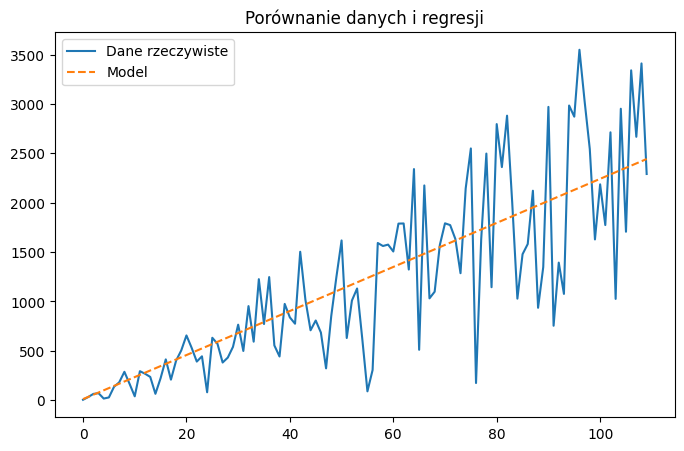

In [9]:
y_pred = A @ coeffs

plt.figure(figsize=(8,5))
plt.plot(y, label="Dane rzeczywiste")
plt.plot(y_pred, linestyle='--', label="Model")
plt.legend()
plt.title("Porównanie danych i regresji")
plt.show()